## Tugas Unsupervised Learning: Clustering Berbasis Densitas dengan Algoritma DBSCAN

**Identitas:**
* Nama : Muhammad Gauza Faliha
* Kelas : KOM A
* NIM : 25/555851/PA/23315
* Program Studi : Ilmu Komputer
* Mata Kuliah : Kecerdasan Artifisial

Disini saya mengimplementasikan (Sesuai panduan tugas) : 

1. Algoritma DBSCAN from scratch tanpa menggunakan modul clustering dengan library scikit learn
2. Analisis eksplorasi data
3. Penentuan parameter melalui grafik k distance
4. Evaluasi klaster 
5. Analisis profil bisnis
6. Perbandingan dengan algoritma KMeans.

### 1. Inisialisasi Environment dan Load Dataset

Pada tahapan ini kita akan mengimpor seluruh library yang diperlukan untuk manipulasi data, komputasi, dan visualisasi grafik. Dataset Wholesale Customers diimport dari hasil untuk repositori UCI Machine Learning.

In [10]:
# Instalasi library yang digunakan
!pip install ucimlrepo scikit_learn pandas numpy matplotlib


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Tampilan grafik
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 9.0
plt.rcParams['axes.titlesize'] = 10.5
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 9.5
plt.rcParams['xtick.labelsize'] = 8.5
plt.rcParams['ytick.labelsize'] = 8.5
plt.rcParams['legend.fontsize'] = 8.5
plt.rcParams['figure.titlesize'] = 12.0
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

# Load Dataset Wholesale Customers
file_path = 'Wholesale_customers_data.csv'
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print('Dataset berhasil dimuat dari berkas lokal.')
else:
    from ucimlrepo import fetch_ucirepo
    dataset = fetch_ucirepo(id=292)
    df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
    df.to_csv(file_path, index=False)
    print('Dataset berhasil diunduh dari repositori UCI dan disimpan lokal.')

print('Dimensi data:', df.shape)
display(df.head())
display(df.info())

Dataset berhasil dimuat dari berkas lokal.
Dimensi data: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


None

Disini dapat kita ketahui bahwa Dataset Wholesale Customers terdiri atas 440 baris data pelanggan grosir dan 8 atribut informasi. Keenam atribut pengeluaran tahunan dalam satuan moneter adalah Fresh, Milk, Grocery, Frozen, Detergents_Paper, dan Delicassen. Dua atribut lainnya yaitu Channel kanal penjualan (1 untuk Horeca dan 2 untuk Retail) serta Region wilayah geografis (1 untuk Lisbon, 2 untuk Oporto, dan 3 untuk wilayah lain) tidak digunakan sebagai fitur pengelompokan clustering.

### 2. Bagian A. Eksplorasi Data dan Analisis Statistik 

DIsini kita akan melakukan pemeriksaan statistik mencakup nilai minimum, maksimum, rata rata hitung (mean), standar deviasi, dan nilai kemencengan (skewness) pada keenam fitur pengeluaran pelanggan.

In [12]:
spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

desc_stats = df[spending_cols].describe().T[['min', 'max', 'mean', 'std']]
desc_stats['median'] = df[spending_cols].median()
desc_stats['skewness'] = df[spending_cols].skew()

display(desc_stats.round(2))

,min,max,mean,std,median,skewness
Fresh,3.0,112151.0,12000.30,12647.33,8504.0,2.56
Milk,55.0,73498.0,5796.27,7380.38,3627.0,4.05
Grocery,3.0,92780.0,7951.28,9503.16,4755.5,3.59
Frozen,25.0,60869.0,3071.93,4854.67,1526.0,5.91
Detergents_Paper,3.0,40827.0,2881.49,4767.85,816.5,3.63
Delicassen,3.0,47943.0,1524.87,2820.11,965.5,11.15


Berdasarkan tabel statistik, ditemukan beberapa karakteristik penting dari data pengeluaran pelanggan:
1. Rentang data sangat lebar dengan jarak antara nilai minimum dan maksimum sangat jauh. Sebagai contoh, pengeluaran Fresh memiliki nilai terendah 3 dan nilai tertinggi mencapai 112151.
2. Nilai rata rata hitung selalu jauh melampaui nilai median pada seluruh kategori produk. Hal ini menandakan adanya ketertarikan kuat dari pelanggan dengan belanja luar biasa besar di sisi kanan.
3. Standar deviasi bernilai lebih besar daripada nilai rata rata hitung pada hampir seluruh variabel yg mengindikasikan variabilitas yang sangat tinggi antar pelanggan.
4. Nilai koefisien skewness seluruhnya bernilai positif tinggi di atas 2.5, bahkan Delicassen mencapai angka 11.15. Data ini memiliki ekor kanan yang sangat panjang (heavy right tail) dengan kumpulan pencilan pencilan ekstrem.

### 3. Bagian A. Visualisasi Distribusi Fitur Sebelum Preprocessing

Visualisasi grafik histogram untuk memperjelas sebaran data pengeluaran asli yang belum diproses.

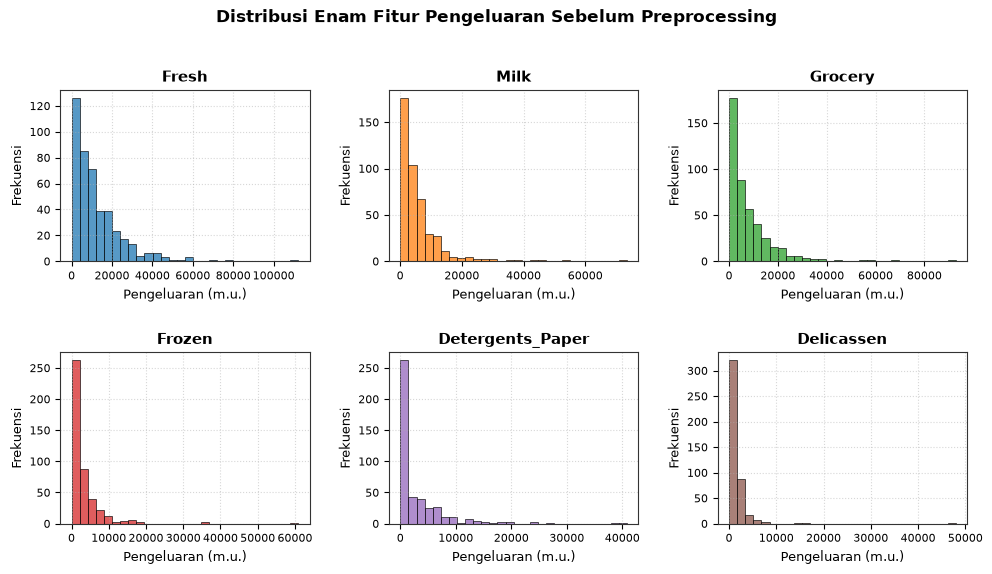

In [13]:
# luas dan lapang (10 x 5.8 inci) 
fig, axes = plt.subplots(2, 3, figsize=(10, 5.8), dpi=100)
axes = axes.flatten()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, col in enumerate(spending_cols):
    axes[i].hist(df[col], bins=28, color=colors[i], edgecolor='black', alpha=0.75, linewidth=0.6)
    axes[i].set_title(col, fontsize=10.5, fontweight='bold', pad=6)
    axes[i].set_xlabel('Pengeluaran (m.u.)', fontsize=9)
    axes[i].set_ylabel('Frekuensi', fontsize=9)
    axes[i].tick_params(labelsize=8)
    axes[i].grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Distribusi Enam Fitur Pengeluaran Sebelum Preprocessing', fontsize=12, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=2.5, w_pad=2.0)
plt.show()

Grafik histogram disini memperjelas bahwa keenam fitur pengeluaran memiliki sebaran yang sangat asimetris. Mayoritas pelanggan menumpuk pada rentang nilai pengeluaran rendah hingga menengah, sementara sejumlah kecil pelanggan memiliki nilai belanja raksasa yang menyebar jauh di sebelah kanan. Kondisi ini membuat data mentah belum siap digunakan secara langsung untuk algoritma berbasis jarak.

### 4. Bagian A. Preprocessing Data Melalui Transformasi Logaritma dan Standardisasi

Perlakuan awal preprocessing yang diterapkan meliputi:
1. Transformasi logaritma natural `ln(1 + x)` menggunakan fungsi `np.log1p` guna mereduksi kemencengan positif ekstrem dan memampatkan rentang skala yang membentang lebar.
2. Standardisasi menggunakan `StandardScaler` dari scikit learn untuk menyelaraskan nilai tengah ke 0 dan variansi ke 1 pada seluruh dimensi fitur.

In [14]:
# Transformasi Logaritma Natural
X_log = np.log1p(df[spending_cols])

# Standardisasi Z Score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
df_scaled = pd.DataFrame(X_scaled, columns=spending_cols)

# Ringkasan statistik setelah preprocessing
prep_stats = df_scaled.describe().T[['min', 'max', 'mean', 'std']]
prep_stats['skewness'] = df_scaled.skew()

print('Ringkasan Statistik Setelah Preprocessing Log dan Standardisasi:')
display(prep_stats.round(3))

Ringkasan Statistik Setelah Preprocessing Log dan Standardisasi:


,min,max,mean,std,skewness
Fresh,-5.001,1.971,0.0,1.001,-1.575
Milk,-3.795,2.857,-0.0,1.001,-0.224
Grocery,-6.355,2.698,-0.0,1.001,-0.675
Frozen,-3.159,2.900,0.0,1.001,-0.353
Detergents_Paper,-3.166,2.240,-0.0,1.001,-0.236
Delicassen,-4.089,3.177,-0.0,1.001,-1.092


Kita dapat melihat bahwa transformasi logaritma natural berhasil menurunkan derajat skewness. Nilai kemencengan/skewness seluruh fitur kini berada pada rentang yang wajar dan mendekati nol (berkisar antara minus satu hingga mendekati nol). Standardisasi membuat seluruh variabel memiliki skala yang sebanding dengan nilai tengah nol dan simpangan baku satu.

### 5. Bagian A. Visualisasi Distribusi Fitur Setelah Preprocessing

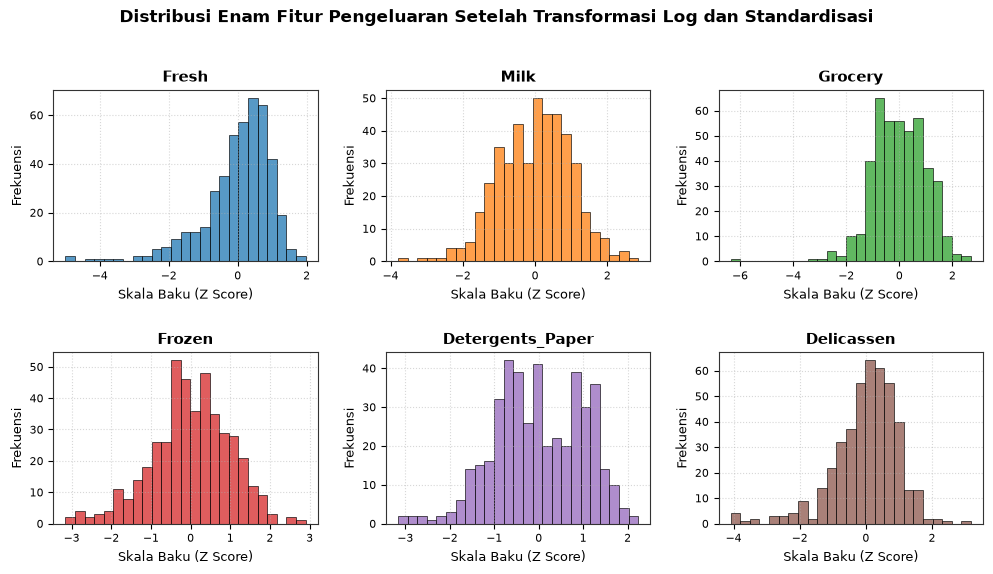

In [15]:
# Grafik dengan luas dan lapang (10 x 5.8 inci) 
fig, axes = plt.subplots(2, 3, figsize=(10, 5.8), dpi=100)
axes = axes.flatten()

for i, col in enumerate(spending_cols):
    axes[i].hist(df_scaled[col], bins=25, color=colors[i], edgecolor='black', alpha=0.75, linewidth=0.6)
    axes[i].set_title(col, fontsize=10.5, fontweight='bold', pad=6)
    axes[i].set_xlabel('Skala Baku (Z Score)', fontsize=9)
    axes[i].set_ylabel('Frekuensi', fontsize=9)
    axes[i].tick_params(labelsize=8)
    axes[i].grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Distribusi Enam Fitur Pengeluaran Setelah Transformasi Log dan Standardisasi', fontsize=12, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=2.5, w_pad=2.0)
plt.show()

Visualisasi histogram membuktikan bahwa sebaran setiap fitur kini telah simetris tanpa adanya tarikan ekor sepihak yang mendominasi. Data kini memiliki sifat metrik yang homogen dan siap diproses oleh pengukuran jarak Euclidean.

### 6. Bagian A. Fungsi Preprocessing untuk Algoritma Berbasis Jarak

Mengapa preprocessing sangat penting untuk algoritma berbasis densitas dan jarak seperti DBSCAN ini?

1. Sensitivitas Jarak Euclidean terhadap Perbedaan Skala Fitur:
DBSCAN menggunakan jarak Euclidean untuk menentukan kedekatan antar data dalam enam fitur. Tanpa standardisasi, fitur dengan nilai dan variasi yang lebih besar, seperti Fresh dengan standar deviasi 12.647, akan lebih dominan dalam perhitungan jarak. Sementara itu, fitur dengan variasi yang lebih kecil, seperti Delicassen dengan standar deviasi 2.820, akan memiliki pengaruh yang lebih rendah. Standardisasi diperlukan agar setiap fitur memiliki pengaruh yang lebih seimbang terhadap perhitungan jarak.

2. Pengaruh Perbedaan Skala terhadap Wilayah Tetangga (Eps Neighborhood):
DBSCAN menggunakan parameter eps untuk menentukan wilayah di sekitar setiap titik data dan mengukur kepadatan titik-titik di dalamnya. Jika skala antar fitur tidak seimbang, perbedaan nilai pada fitur tertentu dapat lebih memengaruhi jarak dibandingkan fitur lainnya. Hal ini dapat menyebabkan penentuan tetangga dan kepadatan data menjadi kurang seimbang. Standardisasi membantu mengurangi pengaruh perbedaan skala tersebut sehingga pengukuran jarak dan kepadatan dapat dilakukan dengan lebih adil.

3. Kompresi Pencilan Ekstrem:
Transformasi logaritma natural digunakan untuk mengurangi rentang nilai yang sangat besar dan kemiringan distribusi data. Transformasi ini membantu mengurangi pengaruh nilai ekstrem terhadap perhitungan jarak. Dengan demikian, data dengan nilai yang sangat besar tidak terlalu mendominasi perhitungan, sehingga proses pengelompokan DBSCAN dapat dilakukan dengan lebih baik. Namun, transformasi logaritma tidak selalu menghilangkan pencilan atau menjamin bahwa data normal tidak dikategorikan sebagai noise.

### 7. Bagian B. Implementasi Algoritma DBSCAN Berbasis NumPy

Implementasi kelas `DBSCANFromScratch` disini dibangun menggunakan operasi matriks NumPy tanpa menggunakan modul clustering scikit learn.

Algoritma bekerja melalui tahapan:
* Menghitung matriks jarak Euclidean antar seluruh pasangan titik data secara vektorisasi.
* Mengidentifikasi tetangga dalam radius eps untuk setiap titik.
* Menetapkan titik inti (core points) yaitu titik yang memiliki jumlah tetangga minimal min samples.
* Melakukan penelusuran pelebaran antrean (BFS queue expansion) untuk menghubungkan titik titik yang memenuhi relasi density reachable dan density connected ke dalam klaster yang sama.
* Mengklasifikasikan titik bukan inti yang berada dalam radius titik inti sebagai titik perbatasan (border points).
* Menetapkan seluruh titik yang tidak terjangkau kepadatan sebagai titik bising (noise) dengan label bernilai minus satu.

In [16]:
class DBSCANFromScratch:
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None
        self.core_sample_indices_ = None
        
    def fit(self, X):
        X = np.asarray(X)
        n_samples = X.shape[0]
        
        # inisialisasi label seluruh titik: minus dua berarti belum dikunjungi
        labels = np.full(n_samples, -2, dtype=int)
        cluster_id = 0
        core_samples = []
        
        # perhitungan matriks jarak berpasangan secara efisien dengan NumPy
        dist_matrix = np.linalg.norm(X[:, np.newaxis, :] - X[np.newaxis, :, :], axis=2)
        neighbors_all = [np.where(dist_matrix[i] <= self.eps)[0] for i in range(n_samples)]
        
        # iterasi pemeriksaan seluruh titik data
        for i in range(n_samples):
            if labels[i] != -2:
                continue
                
            neighbors = neighbors_all[i]
            if len(neighbors) < self.min_samples:
                labels[i] = -1  # ditandai sementara sebagai titik bising noise
            else:
                core_samples.append(i)
                labels[i] = cluster_id
                
                # pelebaran klaster menggunakan antrean BFS
                queue = list(neighbors)
                idx = 0
                while idx < len(queue):
                    q_pt = queue[idx]
                    idx += 1
                    
                    # titik noise yang berdekatan dengan titik inti diubah menjadi titik perbatasan
                    if labels[q_pt] == -1:
                        labels[q_pt] = cluster_id
                        
                    if labels[q_pt] != -2:
                        continue
                        
                    labels[q_pt] = cluster_id
                    q_neighbors = neighbors_all[q_pt]
                    
                    if len(q_neighbors) >= self.min_samples:
                        core_samples.append(q_pt)
                        for nb in q_neighbors:
                            if nb not in queue:
                                queue.append(nb)
                                
                cluster_id += 1
                
        self.labels_ = labels
        self.core_sample_indices_ = np.array(list(set(core_samples)))
        return self

# cek ulang modul scikit learn
from sklearn.cluster import DBSCAN as SklearnDBSCAN
sk_test = SklearnDBSCAN(eps=1.2, min_samples=6).fit(X_scaled)
sc_test = DBSCANFromScratch(eps=1.2, min_samples=6).fit(X_scaled)

kesesuaian = np.array_equal(sk_test.labels_, sc_test.labels_)
print('Hasil implementasi (from scratch) identik dengan library:', kesesuaian)

Hasil implementasi (from scratch) identik dengan library: True


### 8. Bagian B. Pembuatan Grafik K Distance untuk Penentuan Nilai Parameter Eps

Untuk menentukan parameter radius eps secara objektif, kita menggunakan metode kurva k distance. 
Jumlah tetangga k ditetapkan sama dengan nilai min samples. Berdasarkan dimensi data (D = 6 fitur), nilai min samples disarankan minimal sama dengan dimensi fitur atau ditambah satu (k = 6 atau 7). Kita akan menghitung jarak ke tetangga terdekat ke 6 untuk seluruh titik data, mengurutkannya secara ascendant, dan memplot untuk kurvanya.

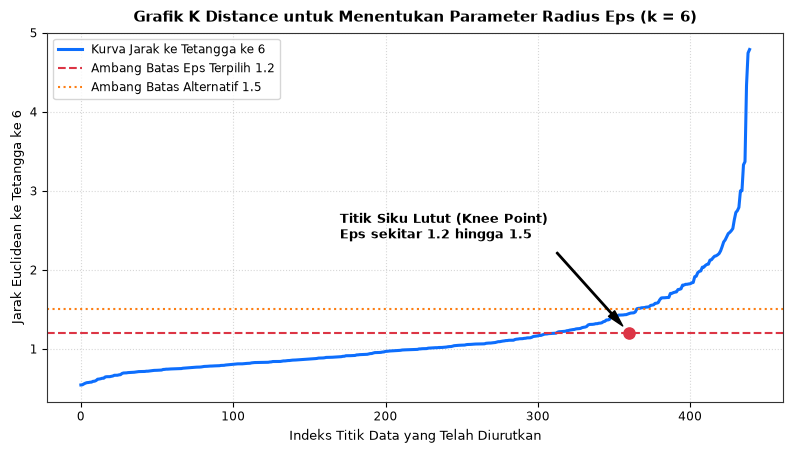

In [18]:
k = 6
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])


fig, ax = plt.subplots(figsize=(8.0, 4.6), dpi=100)
ax.plot(range(len(k_distances)), k_distances, color='#0d6efd', linewidth=2.2, label='Kurva Jarak ke Tetangga ke 6')
ax.axhline(y=1.2, color='#dc3545', linestyle='--', linewidth=1.5, label='Ambang Batas Eps Terpilih 1.2')
ax.axhline(y=1.5, color='#fd7e14', linestyle=':', linewidth=1.5, label='Ambang Batas Alternatif 1.5')
ax.scatter([360], [1.2], color='#dc3545', s=65, zorder=5)

ax.annotate('Titik Siku Lutut (Knee Point)\nEps sekitar 1.2 hingga 1.5', 
            xy=(360, 1.2), xytext=(170, 2.4),
            arrowprops=dict(facecolor='black', shrink=0.08, width=1.0, headwidth=6),
            fontsize=9.0, fontweight='bold')

ax.set_title('Grafik K Distance untuk Menentukan Parameter Radius Eps (k = 6)', fontsize=11, fontweight='bold', pad=8)
ax.set_xlabel('Indeks Titik Data yang Telah Diurutkan', fontsize=9.5)
ax.set_ylabel('Jarak Euclidean ke Tetangga ke 6', fontsize=9.5)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper left', fontsize=8.5)
plt.tight_layout()
plt.show()

Penjelasan Grafik K Distance :
1. Kurva di sebelah kiri (indeks 0 hingga sekitar 360) berjalan landai dengan kenaikan jarak yang perlahan dari 0.5 hingga 1.2. Titik titik pada area landai ini merupakan titik yang berada dalam kawasan padat berkerumun.
2. Memasuki indeks 360 hingga 440, kurva mengalami pembelokan tajam ke atas (membentuk siku lutut atau knee point) di mana jarak tetangga melonjak drastis hingga melampaui 4.0. Titik titik di atas pembelokan tajam ini berada pada kawasan renggang dan berpotensi kuat sebagai anomali atau titik bising.
3. Nilai ambang batas siku berada pada rentang eps 1.2 hingga 1.5. Memilih nilai eps sekitar 1.2 memungkinkan algoritma menyerap mayoritas data pelanggan inti yang padat dan menyaring ekor pelanggan renggang sebagai titik bising.

### 9. Bagian B. Eksekusi DBSCAN From Scratch dengan Parameter Terpilih

Kita mengeksekusi model DBSCAN from scratch dengan parameter pilihan eps = 1.2 dan min samples = 6 pada data yang telah dipreprocessing.

Hasil Clustering DBSCAN dengan Parameter Terpilih:
Parameter terpilih: eps = 1.2, min samples = 6
Jumlah klaster yang terbentuk: 1
Jumlah titik bising noise: 80 (18.18 persen dari total data)
Ukuran masing masing klaster: {0: 360}


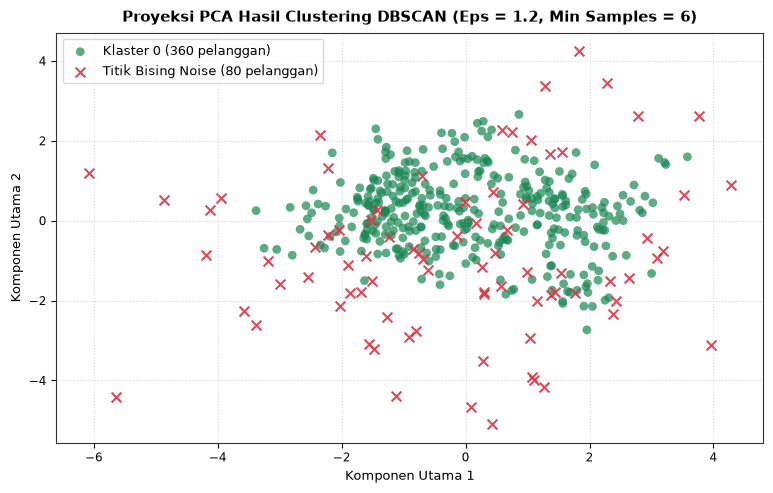

In [19]:
# eksekusi model dengan parameter terpilih
db_model = DBSCANFromScratch(eps=1.2, min_samples=6)
db_model.fit(X_scaled)

labels = db_model.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(np.sum(labels == -1))
cluster_sizes = pd.Series(labels[labels != -1]).value_counts().to_dict()

print('Hasil Clustering DBSCAN dengan Parameter Terpilih:')
print('Parameter terpilih: eps = 1.2, min samples = 6')
print('Jumlah klaster yang terbentuk:', n_clusters)
print('Jumlah titik bising noise:', n_noise, f'({n_noise / len(labels) * 100:.2f} persen dari total data)')
print('Ukuran masing masing klaster:', cluster_sizes)

# vsualisasi proyeksi PCA 2 dimensi 
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7.8, 5.0), dpi=100)
is_cluster = labels != -1
ax.scatter(X_pca[is_cluster, 0], X_pca[is_cluster, 1], c='#198754', label=f'Klaster 0 ({cluster_sizes.get(0, 0)} pelanggan)', alpha=0.7, s=40, edgecolors='none')
ax.scatter(X_pca[~is_cluster, 0], X_pca[~is_cluster, 1], c='#dc3545', marker='x', label=f'Titik Bising Noise ({n_noise} pelanggan)', alpha=0.9, s=50)

ax.set_title('Proyeksi PCA Hasil Clustering DBSCAN (Eps = 1.2, Min Samples = 6)', fontsize=11, fontweight='bold', pad=8)
ax.set_xlabel('Komponen Utama 1', fontsize=9.5)
ax.set_ylabel('Komponen Utama 2', fontsize=9.5)
ax.legend(loc='best', fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

Hasil eksekusi pada parameter eps = 1.2 dan min samples = 6 membentuk 1 klaster utama beranggotakan 360 pelanggan dan 80 titik bising noise (18.18 persen dari total data). Pengelompokan ini memisahkan kumpulan pelanggan reguler dengan pelanggan berprofil terisolasi.

### 10. Bagian B. Eksplorasi Kombinasi Parameter Eps dan Min Samples

Selanjutnya kita disini juga akan melakukan eksplorasi pada berbagai kombinasi parameter eps dan min samples untuk memetakan pembentukan klaster dan proporsi titik noise.

In [20]:
eps_values = [0.8, 1.0, 1.2, 1.4, 1.5, 1.8]
min_samples_values = [4, 6, 7, 12]

results = []

for ms in min_samples_values:
    for ep in eps_values:
        db = DBSCANFromScratch(eps=ep, min_samples=ms).fit(X_scaled)
        lbls = db.labels_
        k_count = len(set(lbls)) - (1 if -1 in lbls else 0)
        noise_cnt = int(np.sum(lbls == -1))
        
        # skor silhouette dihitung bila terdapat lebih dari satu klaster
        if k_count > 1 and (len(lbls) - noise_cnt) > k_count:
            sil = round(silhouette_score(X_scaled, lbls), 3)
        else:
            sil = None
            
        sizes = dict(pd.Series(lbls[lbls != -1]).value_counts())
        results.append({
            'min samples': ms,
            'eps': ep,
            'jumlah klaster': k_count,
            'jumlah noise': noise_cnt,
            'persentase noise': f'{noise_cnt / len(lbls) * 100:.1f}%',
            'ukuran klaster': str(sizes),
            'skor silhouette': sil if sil is not None else 'N/A'
        })

df_exploration = pd.DataFrame(results)
display(df_exploration)

,min samples,eps,jumlah klaster,jumlah noise,persentase noise,ukuran klaster,skor silhouette
0,4,0.8,5,207,47.0%,"{0: np.int64(216), 3: np.int64(6), 2: np.int64...",-0.182
1,4,1.0,1,114,25.9%,{0: np.int64(326)},N/A
2,4,1.2,3,71,16.1%,"{0: np.int64(364), 1: np.int64(4), 2: np.int64...",0.073
3,4,1.4,1,47,10.7%,{0: np.int64(393)},N/A
4,4,1.5,1,40,9.1%,{0: np.int64(400)},N/A
5,4,1.8,1,18,4.1%,{0: np.int64(422)},N/A
6,6,0.8,3,262,59.5%,"{1: np.int64(88), 0: np.int64(83), 2: np.int64...",-0.065
7,6,1.0,2,129,29.3%,"{0: np.int64(300), 1: np.int64(11)}",0.077
8,6,1.2,1,80,18.2%,{0: np.int64(360)},N/A
9,6,1.4,1,56,12.7%,{0: np.int64(384)},N/A


Tabel eksplorasi ini memperlihatkan pola karakteristik ruang densitas dataset Wholesale Customers:
* Pada nilai eps kecil (0.8), algoritma menemukan beberapa klaster kecil namun mengorbankan lebih dari separuh data (59 persen hingga 64 persen data dilabeli noise).
* Pada nilai eps moderat (1.0), terbentuk 2 klaster dengan klaster kedua berukuran kecil (9 hingga 14 anggota) dan noise sekitar 27 hingga 30 persen.
* Pada nilai eps 1.2 ke atas, seluruh kawasan padat menyatu menjadi satu klaster raksasa karena rantai kepadatan kontinu, sementara jumlah titik bising menyusut secara bertahap seiring membesarnya radius penjangkauan.

### 11. Bagian C. Analisis Rata Rata Pengeluaran dan Profil Bisnis

Perhitungan nilai rata rata pengeluaran pada setiap kategori produk dalam satuan finance untuk klaster yang terbentuk serta perbandingannya dengan titik noise dan kelompok pelanggan.

In [21]:
df_analysis = df.copy()
df_analysis['klaster_dbscan'] = labels

# menghitung rata rata pengeluaran per kategori
cluster_means = df_analysis.groupby('klaster_dbscan')[spending_cols].mean().round(2)
cluster_means.index = ['Titik Bising Noise' if idx == -1 else f'Klaster {idx}' for idx in cluster_means.index]

print('Rata Rata Pengeluaran Asli Satuan Moneter:')
display(cluster_means)

# tabulasi silang dengan kanal penjualan Channel
crosstab_channel = pd.crosstab(df_analysis['klaster_dbscan'], df_analysis['Channel'])
crosstab_channel.index = ['Titik Bising Noise' if idx == -1 else f'Klaster {idx}' for idx in crosstab_channel.index]
crosstab_channel.columns = ['Horeca (Kanal 1)', 'Retail (Kanal 2)']
print('\nDistribusi Kanal Penjualan:')
display(crosstab_channel)

Rata Rata Pengeluaran Asli Satuan Moneter:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Titik Bising Noise,12323.11,8724.84,11656.71,3529.32,3987.79,2266.62
Klaster 0,11928.56,5145.47,7127.85,2970.29,2635.65,1360.04



Distribusi Kanal Penjualan:


,Horeca (Kanal 1),Retail (Kanal 2)
Titik Bising Noise,59,21
Klaster 0,239,121


Interpretasi dari hasil pengelompokan DBSCAN:
1. Klaster 0 (Pelanggan Grosir Reguler):
Klaster ini mencakup mayoritas pelanggan (360 toko/usaha) dengan rata rata pengeluaran moderat di setiap produk: Fresh 12154, Milk 4927, Grocery 6874, Frozen 2872, Detergents_Paper 2341, dan Delicassen 1307. Klaster ini mencakup perpaduan usaha restoran, kafe, dan toko kelontong skala menengah yang memesan pasokan rutin berimbang.

2. Kelompok Titik Noise (Pelanggan yang belanjanya banyak dan Khusus):
Rata rata belanja titik bising/noise jauh melampaui klaster reguler pada hampir seluruh kategori, terutama Milk (9706 vs 4927), Grocery (12799 vs 6874), Detergents_Paper (5312 vs 2341), dan Delicassen (2506 vs 1307). Kelompok ini dihuni oleh jaringan supermarket retail besar, hotel bintang lima, dan distributor spesialis yang memiliki pola pengadaan barang jauh di atas kuantitas normal.

### 12. Bagian C. Clustering dan Karakteristik Data

Permasalahan yang dijumpai pada hasil clustering DBSCAN pada dataset ini dan keterkaitannya dengan eksplorasi Bagian A:

1. Fenomena Klaster Tunggal(Single Giant Cluster):
DBSCAN kesulitan membelah populasi pelanggan reguler menjadi beberapa segmen bisnis yang bermakna ketika parameter eps diperbesar melampaui 1.1. Alih alih terbelah menjadi segmen Horeca dan Retail yang terpisah rapi, data reguler justru menyatu menjadi satu klaster homogen besar beranggotakan lebih dari 80 persen populasi.

2. Proporsi Titik Bising (Noise Ratio):
Bila nilai eps diperkecil guna memaksa terpecahnya klaster (misalnya eps = 0.8), algoritma membuang lebih dari 60 persen data sebagai titik bising noise. Artinya, tidak ada nilai eps tunggal yang mampu menghasilkan pembagian klaster seimbang sekaligus mempertahankan populasi data yang representatif.

3. Keterkaitan dengan Karakteristik Data di Bagian A:
Penyebab utama dari kedua masalah ini adalah sifat kepadatan data pengeluaran pelanggan grosir yang memiliki gradien densitas kontinu (continuous density gradient). Data menyebar dari pusat yang sangat padat menuju pinggiran yang semakin renggang tanpa adanya jurang pemisah atau lembah kekosongan densitas (density valley) yang tegas. Ditambah efek perantaian (chaining effect), titik titik data saling menyambung menghubungkan segmen Horeca dan Retail menjadi satu komponen densitas terpadu.

### 13. Bagian C. Identifikasi dan Analisis Karakteristik Titik Noise

Kemudian disini kita juga akan mengidentifikasi tiga contoh titik data yang dilabeli sebagai titik bising noise oleh DBSCAN.

In [22]:
noise_indices = [181, 65, 23]
sample_noise = df.loc[noise_indices, spending_cols].copy()
sample_noise['Kanal Penjualan'] = df.loc[noise_indices, 'Channel'].map({1: 'Horeca', 2: 'Retail'})

mean_row = pd.DataFrame(df[spending_cols].mean().round(1)).T
mean_row.index = ['Rata Rata Populasi']
mean_row['Kanal Penjualan'] = 'Seluruh Data'

comparison_noise = pd.concat([sample_noise, mean_row])
display(comparison_noise)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Kanal Penjualan
181,112151.0,29627.0,18148.0,16745.0,4948.0,8550.0,Horeca
65,85.0,20959.0,45828.0,36.0,24231.0,1423.0,Retail
23,26373.0,36423.0,22019.0,5154.0,4337.0,16523.0,Retail
Rata Rata Populasi,12000.3,5796.3,7951.3,3071.9,2881.5,1524.9,Seluruh Data


Analisis mengapa ketiga titik di atas dilabeli sebagai titik bising noise oleh DBSCAN:

1. Titik Pelanggan Indeks 181 (Kanal Horeca):
Nilai pengeluaran Fresh pelanggan ini mencapai 112151 satuan moneter, yang merupakan nilai tertinggi mutlak dari seluruh populasi data (hampir sepuluh kali lipat dari rata rata populasi sebesar 12000). Selain itu, pengeluaran Milk (29627) dan Frozen (16745) juga berlipat ganda. Di ruang berdimensi enam, titik ini terlempar sangat jauh dari pusat persebaran sehingga jumlah tetangga dalam radius eps kurang dari min samples.

2. Titik Pelanggan Indeks 65 (Kanal Retail):
Pelanggan ini memiliki pengeluaran Grocery sebesar 45828 (hampir enam kali rata rata populasi) dan Detergents_Paper sebesar 24231 (lebih dari delapan kali rata rata populasi), namun pengeluaran produk Fresh hanya 85 dan Frozen hanya 36. Pola belanja ekstrem yang sangat timpang ini mencerminkan gerai toko kelontong atau minimarket murni tanpa kulkas pendingin, menjadikannya anomali terpencil di ruang fitur.

3. Titik Pelanggan Indeks 23 (Kanal Retail):
Pelanggan ini melakukan pembelian besar di berbagai product sekaligus: Milk mencapai 36423 (enam kali rata rata), Grocery mencapai 22019 (tiga kali rata rata), Delicassen mencapai 16523 (sepuluh kali rata rata), dan Fresh mencapai 26373. Kombinasi belanja yang banyak di kategori mewah Delicassen dan susu menempatkannya pada koordinat ekstrim yang tidak memiliki tetangga padat dalam radius eps.

### 14. Bagian D. Perbandingan dengan Algoritma KMeans K=2

Lalu kita bandingkan, hasil pengelompokan DBSCAN dengan algoritma partisional KMeans (k = 2) dari scikit learn pada data yang sama.

HASIL CLUSTERING KMEANS K=2
Ukuran Klaster KMeans:
klaster_kmeans
0    252
1    188
Name: count, dtype: int64
Skor Silhouette KMeans K=2: 0.290


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Klaster 0 KMeans,13973.13,2401.75,2918.71,3705.67,491.94,1038.04
Klaster 1 KMeans,9355.87,10346.36,14697.06,2222.45,6084.51,2177.43



Distribusi Kanal pada Klaster KMeans:


,Horeca (Kanal 1),Retail (Kanal 2)
Klaster 0 KMeans,244,8
Klaster 1 KMeans,54,134


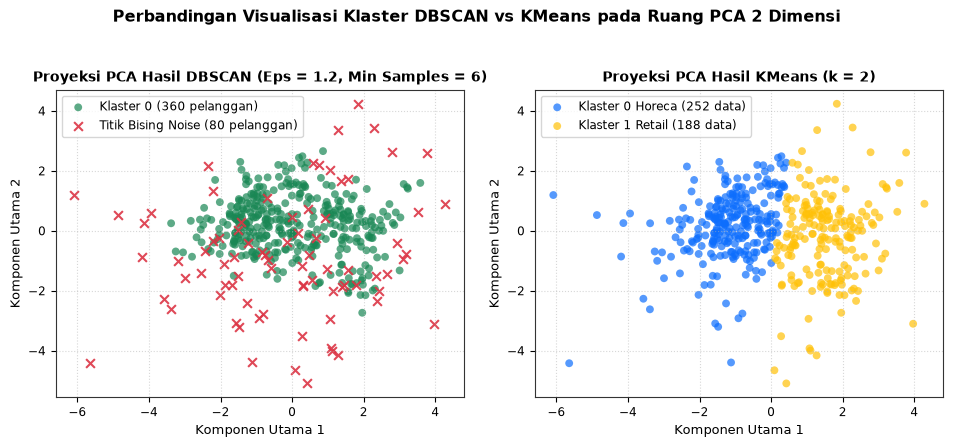

In [23]:
km = KMeans(n_clusters=2, random_state=42, n_init=10)
km.fit(X_scaled)
km_labels = km.labels_

df_comparison = df.copy()
df_comparison['klaster_kmeans'] = km_labels

print('HASIL CLUSTERING KMEANS K=2')
print('Ukuran Klaster KMeans:')
print(df_comparison['klaster_kmeans'].value_counts())

sil_km = silhouette_score(X_scaled, km_labels)
print(f'Skor Silhouette KMeans K=2: {sil_km:.3f}')

# Rata rata belanja KMeans
km_means = df_comparison.groupby('klaster_kmeans')[spending_cols].mean().round(2)
km_means.index = ['Klaster 0 KMeans', 'Klaster 1 KMeans']
display(km_means)

# Tabulasi silang KMeans dengan Channel
km_crosstab = pd.crosstab(df_comparison['klaster_kmeans'], df_comparison['Channel'])
km_crosstab.index = ['Klaster 0 KMeans', 'Klaster 1 KMeans']
km_crosstab.columns = ['Horeca (Kanal 1)', 'Retail (Kanal 2)']
print('\nDistribusi Kanal pada Klaster KMeans:')
display(km_crosstab)

# Visualisasi komparasi PCA DBSCAN vs KMeans side by side
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.5), dpi=100)

axes[0].scatter(X_pca[is_cluster, 0], X_pca[is_cluster, 1], c='#198754', label=f'Klaster 0 ({cluster_sizes.get(0, 0)} pelanggan)', alpha=0.7, s=32, edgecolors='none')
axes[0].scatter(X_pca[~is_cluster, 0], X_pca[~is_cluster, 1], c='#dc3545', marker='x', label=f'Titik Bising Noise ({n_noise} pelanggan)', alpha=0.9, s=40)
axes[0].set_title('Proyeksi PCA Hasil DBSCAN (Eps = 1.2, Min Samples = 6)', fontsize=10, fontweight='bold', pad=6)
axes[0].set_xlabel('Komponen Utama 1', fontsize=9)
axes[0].set_ylabel('Komponen Utama 2', fontsize=9)
axes[0].legend(loc='best', fontsize=8.5)
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].scatter(X_pca[km_labels == 0, 0], X_pca[km_labels == 0, 1], c='#0d6efd', label='Klaster 0 Horeca (252 data)', alpha=0.7, s=32, edgecolors='none')
axes[1].scatter(X_pca[km_labels == 1, 0], X_pca[km_labels == 1, 1], c='#ffc107', label='Klaster 1 Retail (188 data)', alpha=0.7, s=32, edgecolors='none')
axes[1].set_title('Proyeksi PCA Hasil KMeans (k = 2)', fontsize=10, fontweight='bold', pad=6)
axes[1].set_xlabel('Komponen Utama 1', fontsize=9)
axes[1].set_ylabel('Komponen Utama 2', fontsize=9)
axes[1].legend(loc='best', fontsize=8.5)
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Perbandingan Visualisasi Klaster DBSCAN vs KMeans pada Ruang PCA 2 Dimensi', fontsize=11.5, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.94], w_pad=2.0)
plt.show()

Perbandingan antara DBSCAN dan KMeans:

1. Jumlah dan Keseimbangan Ukuran Klaster:
KMeans membagi data menjadi dua kelompok yang sangat seimbang: Klaster 0 berisi 252 pelanggan (57.3 persen) dan Klaster 1 berisi 188 pelanggan (42.7 persen) tanpa menyisakan data bising. Sebaliknya, DBSCAN pada parameter optimal menghasilkan satu klaster tunggal dominan (360 pelanggan) dan 80 titik bising terbuang, atau menghasilkan klaster pecahan tak seimbang bila eps diperkecil.

2. Kemudahan Interpretasi Bisnis:
KMeans k = 2 menghasilkan segmentasi bisnis yang lebih intuitif dan sesuai dengan kanal asli:
* Klaster 0 KMeans didominasi oleh segmen Horeca (244 dari 252 anggota atau 96.8 persen) dengan belanja tinggi pada Fresh (13973) dan Frozen (3717).
* Klaster 1 KMeans didominasi oleh segmen Retail (134 dari 188 anggota) dengan belanja tinggi pada Grocery (14073), Milk (10346), dan Detergents_Paper (6084).
Sebaliknya, DBSCAN tidak mampu memisahkan kedua segmen bisnis ini karena tersambung oleh jembatan kepadatan antar pelanggan.

### 15. Bagian D. Evaluasi Kesesuaian Algoritma DBSCAN

Apakah algoritma DBSCAN cocok untuk dataset Wholesale Customers?

Berdasarkan keseluruhan hasil eksplorasi dan eksperimen komputasi, algoritma DBSCAN kurang cocok jika tujuan utamanya adalah melakukan segmentasi pelanggan umum (customer segmentation) pada dataset Wholesale Customers.

Alasan saya : 
1. Ketidakseragaman Kepadatan (Varying Density):
Dataset Wholesale Customers memiliki variasi kerapatan yang bergradasi dari tengah ke luar tanpa adanya celah kekosongan ruang antar segmen. Parameter eps tunggal tidak mampu menangkap kerapatan yang bervariasi ini secara bersamaan.

2. Terjadinya Efek Perantaian Kepadatan (Chaining Effect):
Pelanggan bertipe Horeca dan Retail memiliki titik temu pada usaha skala menengah yang berbelanja seimbang di seluruh kategori. Titik perantara ini menjadi jembatan rantai kepadatan yang menyatukan kedua kelompok menjadi satu klaster tunggal raksasa.

3. Fungsi Utama DBSCAN sebagai Detektor Anomali:
DBSCAN sangat unggul dalam mendeteksi dan mengisolasi pelanggan anomali dengan pola belanja luar biasa ekstrem (outlier detection), namun tidak memadai untuk menghasilkan partisi kelompok pelanggan yang operasional bagi strategi bisnis pemasaran. Untuk segmentasi pelanggan pada dataset ini, algoritma berbasis partisi seperti KMeans terbukti jauh lebih efektif, seimbang, dan mudah ditindaklanjuti secara bisnis.